# Stage 2: Under-Provisioning Deep Analysis
**Cloud Resource Optimisation Thesis — Frankfurt School of Finance and Management**  
**Author:** Prarthana Govindaraj  
**Date:** May 2026  

---

## Research Questions
1. What does the profile of an under-provisioned job look like in detail?
2. At what CPU request thresholds does under-provisioning risk spike?
3. Can we predict the severity of under-provisioning (how much, not just whether)?
4. What corrected allocation should we recommend per job, with confidence bounds?

## Structure
- Section 0: Load Stage 1b outputs
- Section 1: Deep profile of under-provisioned jobs
- Section 2: Threshold and signal analysis
- Section 3: Severity prediction (regression on util_ratio_peak)
- Section 4: Corrected allocation engine with confidence bounds
- Section 5: Summary and findings

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [13]:
BASE_DIR      = Path('/Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

df    = pd.read_csv(PROCESSED_DIR / 'stage1b_merged_clean.csv')
total = len(df)

under_df     = df[df['is_underprovision'] == 1].copy()
not_under_df = df[df['is_underprovision'] == 0].copy()

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"\nTotal jobs            : {total:,}")
print(f"Under-provisioned     : {len(under_df):,} ({len(under_df)/total*100:.1f}%)")
print(f"Not under-provisioned : {len(not_under_df):,} ({len(not_under_df)/total*100:.1f}%)")
print(f"\nColumns: {list(df.columns)}")
print(f"\nProvisioning class distribution:")
for cls in ['severely_under', 'under', 'efficient', 'over']:
    count = (df['provisioning_class'] == cls).sum()
    print(f"  {cls:<20}: {count:>6,} ({count/total*100:.1f}%)")
print(f"\nutil_ratio_peak stats:")
print(df['util_ratio_peak'].describe().round(3))
print(f"\nSeverity breakdown within under-provisioned only:")
for cls in ['severely_under', 'under']:
    count = (under_df['provisioning_class'] == cls).sum()
    print(f"  {cls:<20}: {count:>6,} ({count/len(under_df)*100:.1f}% of under-provisioned)")
print(f"\nReady for Section 1")

DATA LOADED

Total jobs            : 11,644
Under-provisioned     : 5,149 (44.2%)
Not under-provisioned : 6,495 (55.8%)

Columns: ['job_name', 'plan_cpu_cores', 'task_count', 'cpu_avg_peak', 'cpu_max_peak', 'instance_count', 'cpu_avg_mean', 'cpu_avg_std', 'cpu_avg_max', 'util_ratio_avg', 'util_ratio_peak', 'provisioning_class', 'is_underprovision', 'plan_cpu_per_task', 'instance_to_task_ratio', 'is_multi_task', 'is_large_job', 'size_bucket', 'cpu_size_bucket_encoded']

Provisioning class distribution:
  severely_under      :  3,225 (27.7%)
  under               :  1,924 (16.5%)
  efficient           :  3,206 (27.5%)
  over                :  3,289 (28.2%)

util_ratio_peak stats:
count    11644.000
mean         1.625
std          2.343
min          0.019
25%          0.412
50%          0.868
75%          1.790
max         31.000
Name: util_ratio_peak, dtype: float64

Severity breakdown within under-provisioned only:
  severely_under      :  3,225 (62.6% of under-provisioned)
  under     

---
## Section 1: Deep Profile of Under-Provisioned Jobs

SECTION 1: SEVERITY BREAKDOWN

Severity distribution among 5,149 under-provisioned jobs:
  Mild (1.0-1.5)           : 1,549 (30.1%)
  Moderate (1.5-2.0)       :   635 (12.3%)
  Severe (2.0-3.0)         :   811 (15.8%)
  Extreme (3.0+)           : 1,678 (32.6%)


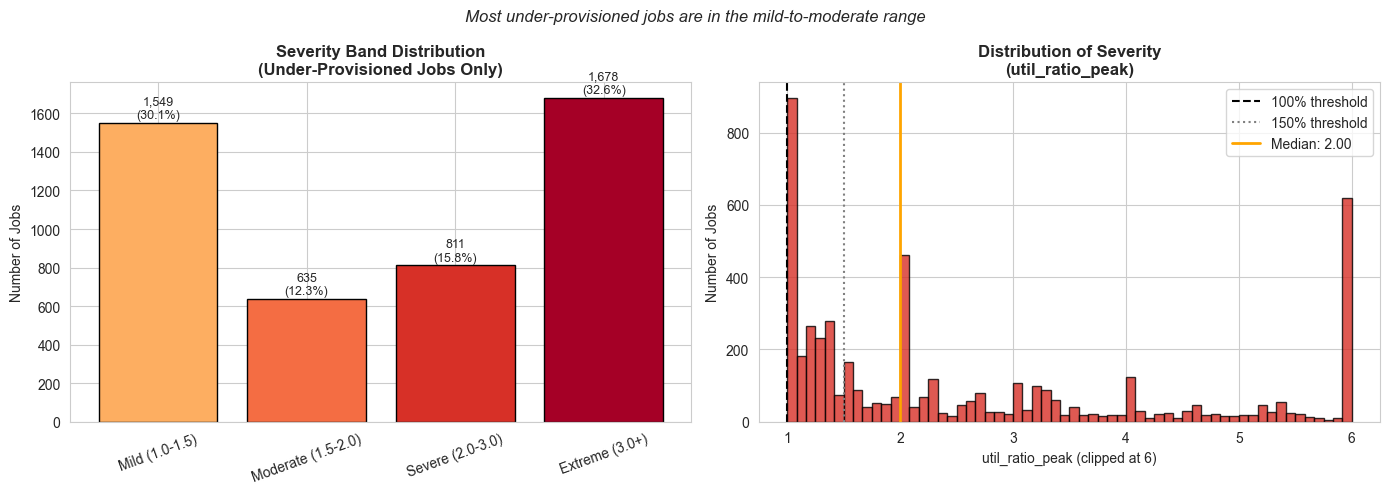

In [14]:
print("=" * 60)
print("SECTION 1: SEVERITY BREAKDOWN")
print("=" * 60)

severity_bins   = [1.0, 1.5, 2.0, 3.0, 100]
severity_labels = ['Mild (1.0-1.5)', 'Moderate (1.5-2.0)', 'Severe (2.0-3.0)', 'Extreme (3.0+)']

under_df['severity_band'] = pd.cut(
    under_df['util_ratio_peak'],
    bins=severity_bins,
    labels=severity_labels
)

print(f"\nSeverity distribution among {len(under_df):,} under-provisioned jobs:")
for band in severity_labels:
    count = (under_df['severity_band'] == band).sum()
    print(f"  {band:<25}: {count:>5,} ({count/len(under_df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = [(under_df['severity_band'] == b).sum() for b in severity_labels]
colors = ['#fdae61', '#f46d43', '#d73027', '#a50026']
axes[0].bar(severity_labels, counts, color=colors, edgecolor='black')
axes[0].set_title('Severity Band Distribution\n(Under-Provisioned Jobs Only)', fontweight='bold')
axes[0].set_ylabel('Number of Jobs')
axes[0].tick_params(axis='x', rotation=20)
for bar, count in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{count:,}\n({count/len(under_df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

axes[1].hist(under_df['util_ratio_peak'].clip(upper=6),
             bins=60, color='#d73027', edgecolor='black', alpha=0.8)
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='100% threshold')
axes[1].axvline(1.5, color='grey',  linestyle=':',  linewidth=1.5, label='150% threshold')
axes[1].axvline(under_df['util_ratio_peak'].median(), color='orange',
                linestyle='-', linewidth=2,
                label=f"Median: {under_df['util_ratio_peak'].median():.2f}")
axes[1].set_xlabel('util_ratio_peak (clipped at 6)')
axes[1].set_ylabel('Number of Jobs')
axes[1].set_title('Distribution of Severity\n(util_ratio_peak)', fontweight='bold')
axes[1].legend()

plt.suptitle('Most under-provisioned jobs are in the mild-to-moderate range',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

SECTION 1: JOB STRUCTURE PROFILE

Feature                     Under mean   Under median     Not mean     Not median
--------------------------------------------------------------------------------
  plan_cpu_cores                  2.32           1.50         4.66           3.00
  task_count                      1.06           1.00         1.17           1.00
  instance_count                869.92         251.00       900.96          83.00
  instance_to_task_ratio        685.52         247.00       617.56          83.00


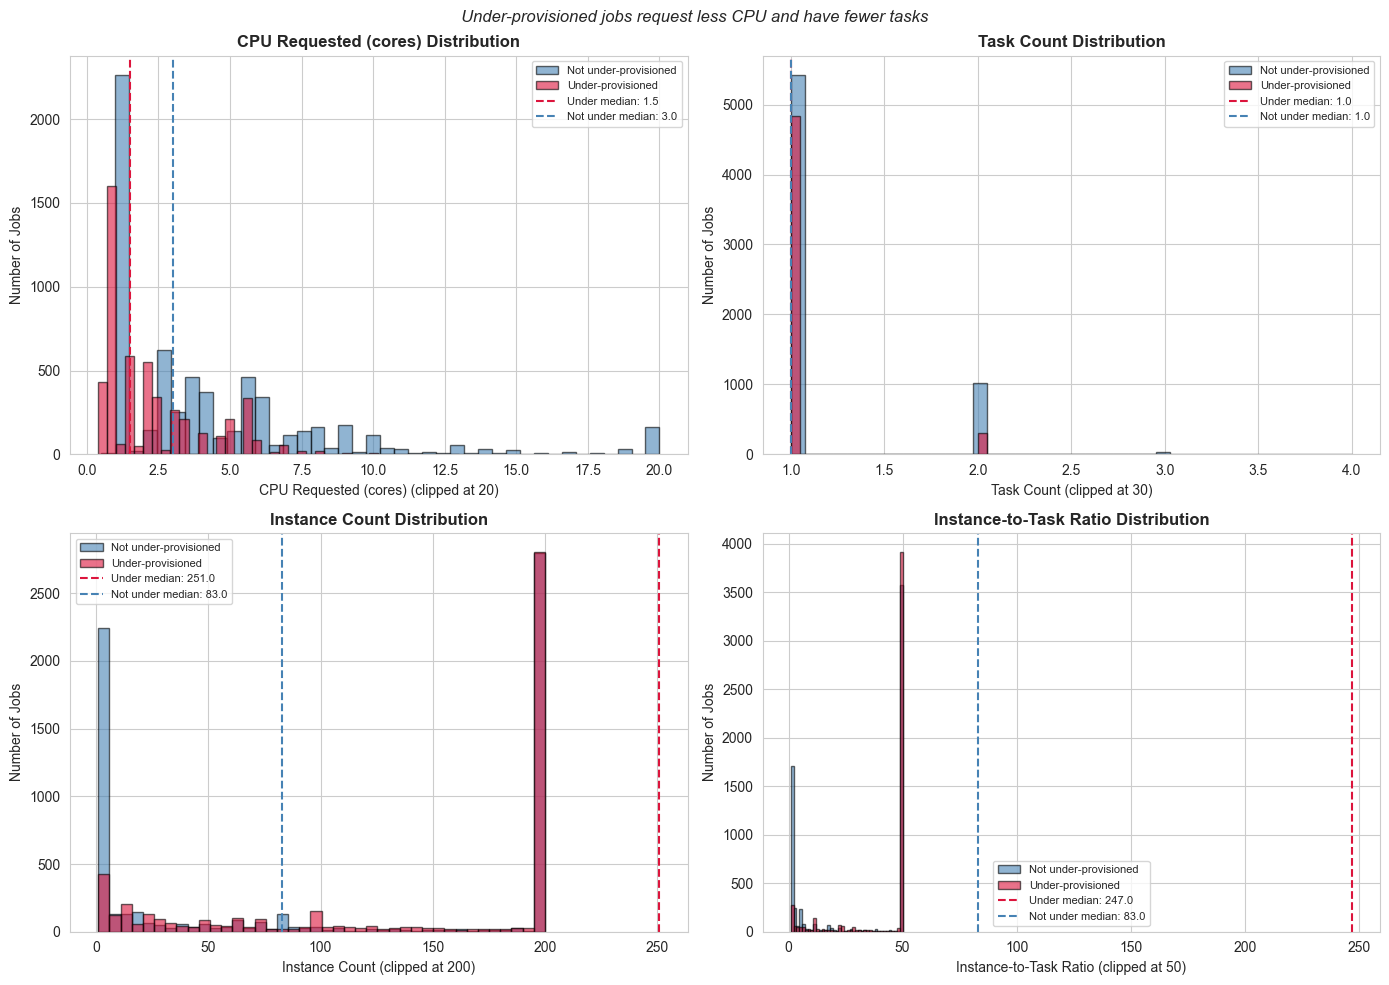

In [15]:
print("=" * 60)
print("SECTION 1: JOB STRUCTURE PROFILE")
print("=" * 60)

profile_cols = ['plan_cpu_cores', 'task_count', 'instance_count', 'instance_to_task_ratio']

print(f"\n{'Feature':<25} {'Under mean':>12} {'Under median':>14} {'Not mean':>12} {'Not median':>14}")
print("-" * 80)
for col in profile_cols:
    if col in under_df.columns:
        print(
            f"  {col:<23}"
            f" {under_df[col].mean():>12.2f}"
            f" {under_df[col].median():>14.2f}"
            f" {not_under_df[col].mean():>12.2f}"
            f" {not_under_df[col].median():>14.2f}"
        )

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_configs = [
    ('plan_cpu_cores',         20,  'CPU Requested (cores)'),
    ('task_count',             30,  'Task Count'),
    ('instance_count',         200, 'Instance Count'),
    ('instance_to_task_ratio', 50,  'Instance-to-Task Ratio'),
]

for ax, (col, clip_val, label) in zip(axes, plot_configs):
    if col not in under_df.columns:
        continue
    ax.hist(not_under_df[col].clip(upper=clip_val),
            bins=40, alpha=0.6, color='steelblue', edgecolor='black',
            label='Not under-provisioned')
    ax.hist(under_df[col].clip(upper=clip_val),
            bins=40, alpha=0.6, color='crimson', edgecolor='black',
            label='Under-provisioned')
    ax.axvline(under_df[col].median(), color='crimson', linestyle='--', linewidth=1.5,
               label=f'Under median: {under_df[col].median():.1f}')
    ax.axvline(not_under_df[col].median(), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'Not under median: {not_under_df[col].median():.1f}')
    ax.set_xlabel(f'{label} (clipped at {clip_val})')
    ax.set_ylabel('Number of Jobs')
    ax.set_title(f'{label} Distribution', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Under-provisioned jobs request less CPU and have fewer tasks',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

SECTION 1: SINGLE-TASK vs MULTI-TASK RISK

Single-task jobs : 10,266 total — 47.1% under-provisioned
Multi-task jobs  : 1,378 total — 22.6% under-provisioned

Single-task jobs are 2.1x more likely to be under-provisioned


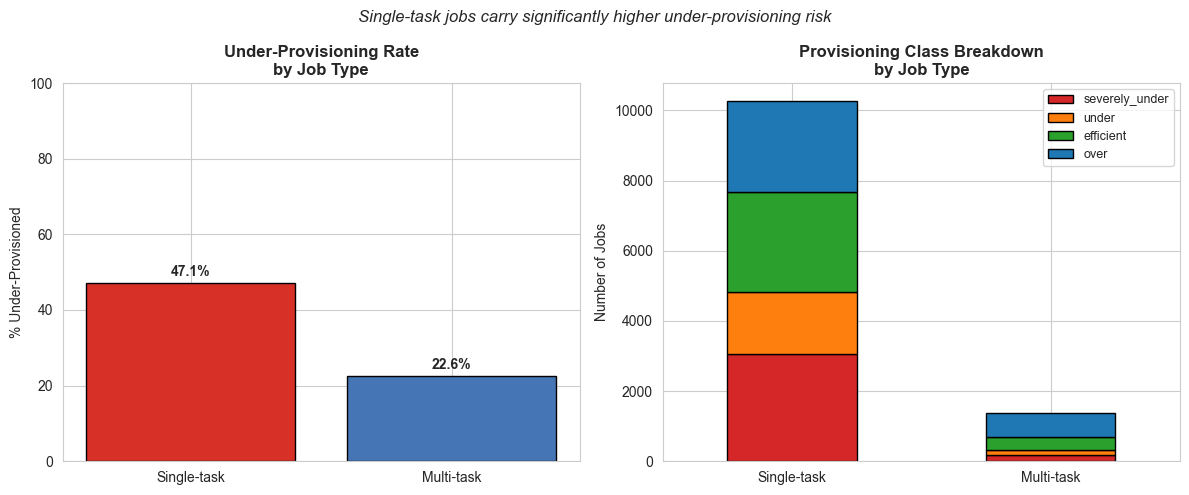

In [16]:
print("=" * 60)
print("SECTION 1: SINGLE-TASK vs MULTI-TASK RISK")
print("=" * 60)

df['is_multi_task'] = (df['task_count'] > 1).astype(int)
under_df  = df[df['is_underprovision'] == 1].copy()
not_under_df = df[df['is_underprovision'] == 0].copy()

single_task = df[df['is_multi_task'] == 0]
multi_task  = df[df['is_multi_task'] == 1]

single_under_pct = single_task['is_underprovision'].mean() * 100
multi_under_pct  = multi_task['is_underprovision'].mean()  * 100

print(f"\nSingle-task jobs : {len(single_task):,} total — {single_under_pct:.1f}% under-provisioned")
print(f"Multi-task jobs  : {len(multi_task):,} total — {multi_under_pct:.1f}% under-provisioned")
print(f"\nSingle-task jobs are {single_under_pct/multi_under_pct:.1f}x more likely to be under-provisioned")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Single-task', 'Multi-task'],
            [single_under_pct, multi_under_pct],
            color=['#d73027', '#4575b4'], edgecolor='black')
axes[0].set_ylabel('% Under-Provisioned')
axes[0].set_title('Under-Provisioning Rate\nby Job Type', fontweight='bold')
axes[0].set_ylim(0, 100)
for bar, val in zip(axes[0].patches, [single_under_pct, multi_under_pct]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

severity_by_type = df.groupby(['is_multi_task', 'provisioning_class']).size().unstack(fill_value=0)
severity_by_type.index = ['Single-task', 'Multi-task']
severity_col_order = [c for c in ['severely_under', 'under', 'efficient', 'over']
                      if c in severity_by_type.columns]
severity_by_type[severity_col_order].plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'],
    edgecolor='black'
)
axes[1].set_title('Provisioning Class Breakdown\nby Job Type', fontweight='bold')
axes[1].set_ylabel('Number of Jobs')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Single-task jobs carry significantly higher under-provisioning risk',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

SECTION 1: SIZE BUCKET RISK PROFILE

Size Bucket             Total    Under    Under %    Avg Ratio    Med Ratio
---------------------------------------------------------------------------
  Huge (10+)              484        4       0.8%         0.25         0.15
  Large (2-5)           3,253    1,309      40.2%         1.19         0.81
  Medium (1-2)          1,409    1,241      88.1%         2.71         2.00
  Small (0.5-1)         3,867    1,602      41.4%         1.85         0.90
  Tiny (0-0.5)            438      432      98.6%         5.94         4.00
  XLarge (5-10)         2,193      561      25.6%         0.61         0.37


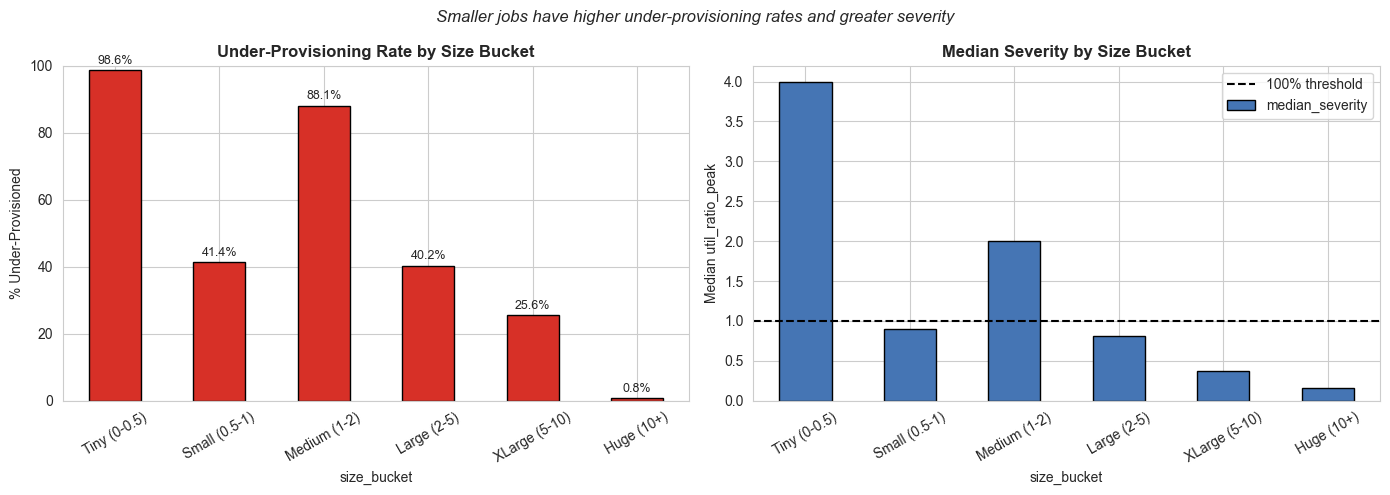

In [17]:
print("=" * 60)
print("SECTION 1: SIZE BUCKET RISK PROFILE")
print("=" * 60)

risk_by_bucket = df.groupby('size_bucket').agg(
    total=('is_underprovision', 'count'),
    under_count=('is_underprovision', 'sum'),
    avg_severity=('util_ratio_peak', 'mean'),
    median_severity=('util_ratio_peak', 'median')
).reset_index()

risk_by_bucket['under_pct'] = risk_by_bucket['under_count'] / risk_by_bucket['total'] * 100

print(f"\n{'Size Bucket':<20} {'Total':>8} {'Under':>8} {'Under %':>10} {'Avg Ratio':>12} {'Med Ratio':>12}")
print("-" * 75)
for _, row in risk_by_bucket.iterrows():
    print(
        f"  {str(row['size_bucket']):<18}"
        f" {int(row['total']):>8,}"
        f" {int(row['under_count']):>8,}"
        f" {row['under_pct']:>9.1f}%"
        f" {row['avg_severity']:>12.2f}"
        f" {row['median_severity']:>12.2f}"
    )

bucket_order = ['Tiny (0-0.5)', 'Small (0.5-1)', 'Medium (1-2)',
                'Large (2-5)', 'XLarge (5-10)', 'Huge (10+)']

risk_plot = risk_by_bucket.set_index('size_bucket').reindex(
    [b for b in bucket_order if b in risk_by_bucket['size_bucket'].values]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_plot['under_pct'].plot(kind='bar', ax=axes[0], color='#d73027', edgecolor='black')
axes[0].set_title('Under-Provisioning Rate by Size Bucket', fontweight='bold')
axes[0].set_ylabel('% Under-Provisioned')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 100)
for bar, val in zip(axes[0].patches, risk_plot['under_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

risk_plot['median_severity'].plot(kind='bar', ax=axes[1], color='#4575b4', edgecolor='black')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='100% threshold')
axes[1].set_title('Median Severity by Size Bucket', fontweight='bold')
axes[1].set_ylabel('Median util_ratio_peak')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle('Smaller jobs have higher under-provisioning rates and greater severity',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

---
### Section 1 Observations

1. **Severity is skewed toward extremes** — while 30.1% of under-provisioned jobs
   fall in the mild range (1.0-1.5x), 32.6% are extreme (3x+). The median severity
   is 2.0, meaning the typical under-provisioned job uses double its requested CPU.
   The spike at the clip ceiling (6x) suggests real severity is even higher in
   many cases.

2. **Under-provisioned jobs request less CPU but have more instances** — they cluster
   at 1-2 core requests vs 2-3 cores for not-under-provisioned jobs. Counterintuitively,
   under-provisioned jobs have significantly more instances (median 251 vs 83). This
   suggests jobs are being scaled out in instances rather than scaled up in CPU —
   a structural signal worth investigating.

3. **Task count alone does not discriminate** — both groups have a median task count
   of 1.0, meaning task count is not a useful standalone signal for identifying
   under-provisioned jobs.

4. **Single-task jobs carry nearly double the risk** — 47.1% of single-task jobs
   are under-provisioned vs 22.6% of multi-task jobs.

5. **Size bucket is the strongest signal** — Tiny jobs (0-0.5 cores) are
   under-provisioned 98.6% of the time with a median severity of 4.0x. Medium
   jobs (1-2 cores) are under-provisioned 88.1% of the time. At the other extreme,
   Huge jobs (10+ cores) are under-provisioned only 0.8% of the time.

**Key finding:** Under-provisioning is almost entirely a small-job phenomenon.
Jobs requesting under 2 cores face an overwhelming likelihood of being
under-provisioned, often severely. Large jobs are almost never under-provisioned.

---
## Section 2: Threshold and Signal Analysis

We know small jobs are high risk. Now we find the exact thresholds where
under-provisioning risk spikes, and which feature combinations are most
predictive of severity.

SECTION 2: CPU REQUEST THRESHOLD ANALYSIS

 CPU Request    Total    Under    Under %   Med Severity
----------------------------------------------------------
       0-0.5      438      432      98.6%           4.00
       0.5-1    3,867    1,602      41.4%           0.90
       1-1.5      665      643      96.7%           2.67
       1.5-2      744      598      80.4%           1.50
       2-2.5      963      351      36.4%           0.81
       2.5-3      546      288      52.7%           1.00
         3-4    1,186      342      28.8%           0.59
         4-5      558      328      58.8%           1.05
       5-7.5    1,642      520      31.7%           0.37
      7.5-10      551       41       7.4%           0.33
         10+      484        4       0.8%           0.15


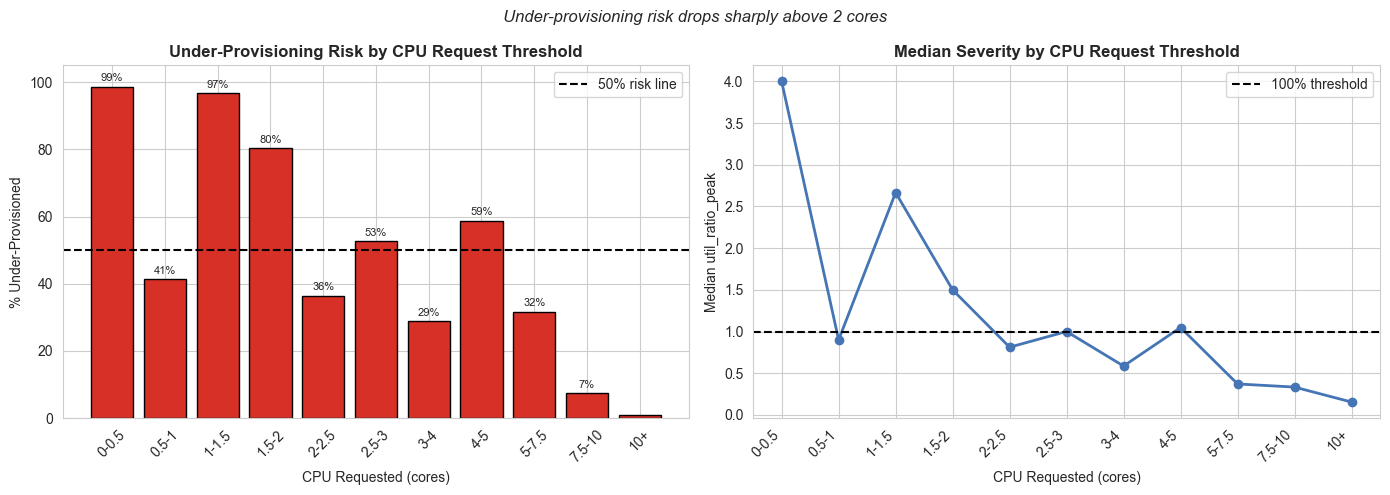

In [18]:
print("=" * 60)
print("SECTION 2: CPU REQUEST THRESHOLD ANALYSIS")
print("=" * 60)

# Bin CPU requests into fine-grained buckets and compute risk at each level
cpu_bins = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.5, 10.0, 1000]
cpu_labels = ['0-0.5', '0.5-1', '1-1.5', '1.5-2', '2-2.5',
              '2.5-3', '3-4', '4-5', '5-7.5', '7.5-10', '10+']

df['cpu_bin'] = pd.cut(df['plan_cpu_cores'], bins=cpu_bins, labels=cpu_labels)

threshold_df = df.groupby('cpu_bin').agg(
    total=('is_underprovision', 'count'),
    under_count=('is_underprovision', 'sum'),
    avg_severity=('util_ratio_peak', 'mean'),
    median_severity=('util_ratio_peak', 'median')
).reset_index()

threshold_df['under_pct'] = threshold_df['under_count'] / threshold_df['total'] * 100

print(f"\n{'CPU Request':>12} {'Total':>8} {'Under':>8} {'Under %':>10} {'Med Severity':>14}")
print("-" * 58)
for _, row in threshold_df.iterrows():
    print(
        f"  {str(row['cpu_bin']):>10}"
        f" {int(row['total']):>8,}"
        f" {int(row['under_count']):>8,}"
        f" {row['under_pct']:>9.1f}%"
        f" {row['median_severity']:>14.2f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(threshold_df['cpu_bin'], threshold_df['under_pct'],
            color='#d73027', edgecolor='black')
axes[0].axhline(50, color='black', linestyle='--', linewidth=1.5, label='50% risk line')
axes[0].set_xlabel('CPU Requested (cores)')
axes[0].set_ylabel('% Under-Provisioned')
axes[0].set_title('Under-Provisioning Risk by CPU Request Threshold', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 105)
axes[0].legend()
for bar, val in zip(axes[0].patches, threshold_df['under_pct']):
    if val > 5:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

axes[1].plot(range(len(threshold_df)), threshold_df['median_severity'],
             color='#4575b4', marker='o', linewidth=2, markersize=6)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='100% threshold')
axes[1].set_xticks(range(len(threshold_df)))
axes[1].set_xticklabels(threshold_df['cpu_bin'], rotation=45, ha='right')
axes[1].set_xlabel('CPU Requested (cores)')
axes[1].set_ylabel('Median util_ratio_peak')
axes[1].set_title('Median Severity by CPU Request Threshold', fontweight='bold')
axes[1].legend()

plt.suptitle('Under-provisioning risk drops sharply above 2 cores',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

SECTION 2: INSTANCE COUNT AS A SIGNAL

 Instance Count    Total    Under    Under %   Med Severity
------------------------------------------------------------
           1-10    2,922      548      18.8%           0.58
          11-50    1,279      718      56.1%           1.00
         51-100    1,078      578      53.6%           1.00
        101-250    1,090      730      67.0%           1.54
        251-500      940      621      66.1%           1.51
           500+    4,335    1,954      45.1%           0.81


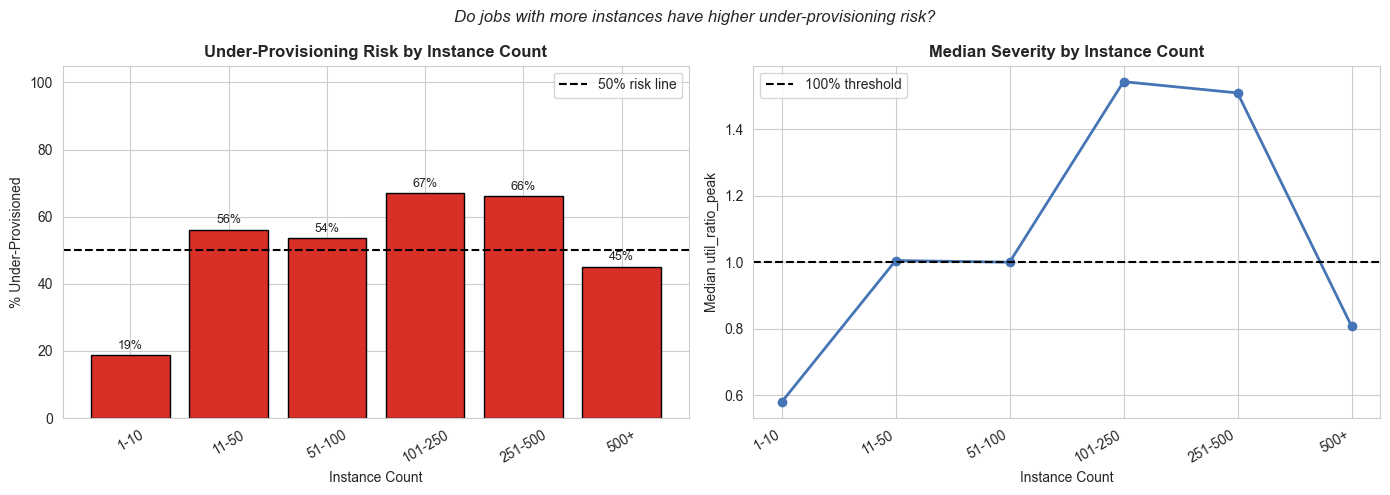

In [19]:
print("=" * 60)
print("SECTION 2: INSTANCE COUNT AS A SIGNAL")
print("=" * 60)

# Instance count was counterintuitive in Section 1 — under-provisioned jobs
# had MORE instances. Investigate whether instance count predicts severity.

instance_bins   = [0, 10, 50, 100, 250, 500, 100000]
instance_labels = ['1-10', '11-50', '51-100', '101-250', '251-500', '500+']

df['instance_bin'] = pd.cut(df['instance_count'], bins=instance_bins, labels=instance_labels)

instance_df = df.groupby('instance_bin').agg(
    total=('is_underprovision', 'count'),
    under_count=('is_underprovision', 'sum'),
    avg_severity=('util_ratio_peak', 'mean'),
    median_severity=('util_ratio_peak', 'median')
).reset_index()

instance_df['under_pct'] = instance_df['under_count'] / instance_df['total'] * 100

print(f"\n{'Instance Count':>15} {'Total':>8} {'Under':>8} {'Under %':>10} {'Med Severity':>14}")
print("-" * 60)
for _, row in instance_df.iterrows():
    print(
        f"  {str(row['instance_bin']):>13}"
        f" {int(row['total']):>8,}"
        f" {int(row['under_count']):>8,}"
        f" {row['under_pct']:>9.1f}%"
        f" {row['median_severity']:>14.2f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(instance_df['instance_bin'], instance_df['under_pct'],
            color='#d73027', edgecolor='black')
axes[0].axhline(50, color='black', linestyle='--', linewidth=1.5, label='50% risk line')
axes[0].set_xlabel('Instance Count')
axes[0].set_ylabel('% Under-Provisioned')
axes[0].set_title('Under-Provisioning Risk by Instance Count', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 105)
axes[0].legend()
for bar, val in zip(axes[0].patches, instance_df['under_pct']):
    if val > 5:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

axes[1].plot(range(len(instance_df)), instance_df['median_severity'],
             color='#4575b4', marker='o', linewidth=2, markersize=6)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='100% threshold')
axes[1].set_xticks(range(len(instance_df)))
axes[1].set_xticklabels(instance_df['instance_bin'], rotation=30, ha='right')
axes[1].set_xlabel('Instance Count')
axes[1].set_ylabel('Median util_ratio_peak')
axes[1].set_title('Median Severity by Instance Count', fontweight='bold')
axes[1].legend()

plt.suptitle('Do jobs with more instances have higher under-provisioning risk?',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

SECTION 2: INTERACTION EFFECTS


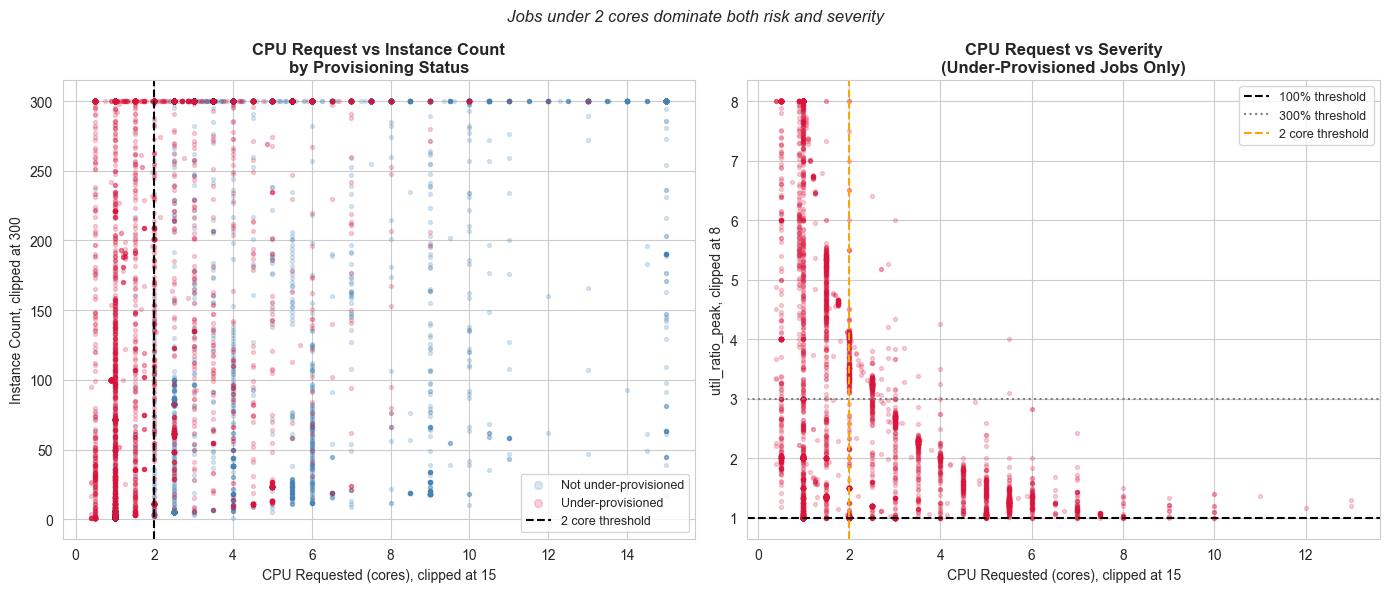


Correlation with util_ratio_peak (under-provisioned jobs only):
  plan_cpu_cores                :  -0.366
  plan_cpu_per_task             :  -0.350
  task_count                    :  -0.067
  instance_count                :  -0.040
  instance_to_task_ratio        :  -0.031


In [20]:
print("=" * 60)
print("SECTION 2: INTERACTION EFFECTS")
print("=" * 60)

# Key question: is it CPU request alone driving risk, or does instance count
# interact with CPU request to produce the worst cases?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

under_scatter     = df[df['is_underprovision'] == 1]
not_under_scatter = df[df['is_underprovision'] == 0]

axes[0].scatter(not_under_scatter['plan_cpu_cores'].clip(upper=15),
                not_under_scatter['instance_count'].clip(upper=300),
                alpha=0.2, s=8, color='steelblue', label='Not under-provisioned')
axes[0].scatter(under_scatter['plan_cpu_cores'].clip(upper=15),
                under_scatter['instance_count'].clip(upper=300),
                alpha=0.2, s=8, color='crimson', label='Under-provisioned')
axes[0].axvline(2.0, color='black', linestyle='--', linewidth=1.5, label='2 core threshold')
axes[0].set_xlabel('CPU Requested (cores), clipped at 15')
axes[0].set_ylabel('Instance Count, clipped at 300')
axes[0].set_title('CPU Request vs Instance Count\nby Provisioning Status', fontweight='bold')
axes[0].legend(markerscale=2, fontsize=9)

axes[1].scatter(under_scatter['plan_cpu_cores'].clip(upper=15),
                under_scatter['util_ratio_peak'].clip(upper=8),
                alpha=0.2, s=8, color='crimson')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='100% threshold')
axes[1].axhline(3.0, color='grey',  linestyle=':',  linewidth=1.5, label='300% threshold')
axes[1].axvline(2.0, color='orange', linestyle='--', linewidth=1.5, label='2 core threshold')
axes[1].set_xlabel('CPU Requested (cores), clipped at 15')
axes[1].set_ylabel('util_ratio_peak, clipped at 8')
axes[1].set_title('CPU Request vs Severity\n(Under-Provisioned Jobs Only)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Jobs under 2 cores dominate both risk and severity',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

# Correlation of features with severity (among under-provisioned only)
print("\nCorrelation with util_ratio_peak (under-provisioned jobs only):")
feature_cols = ['plan_cpu_cores', 'task_count', 'instance_count',
                'instance_to_task_ratio', 'plan_cpu_per_task']
available = [c for c in feature_cols if c in under_df.columns]
corr = under_df[available + ['util_ratio_peak']].corr()['util_ratio_peak'].drop('util_ratio_peak')
for feat, val in corr.sort_values().items():
    print(f"  {feat:<30}: {val:>7.3f}")

---
### Section 2 Observations

1. **The critical threshold is not a clean cutoff — it is non-linear.** The highest
   risk bands are 0-0.5 cores (99%), 1-1.5 cores (97%), and 1.5-2 cores (80%).
   The 0.5-1 core band drops to 41% — an unexpected dip — before risk spikes again
   at 1-1.5 cores. This suggests the dataset contains two distinct small-job
   populations with different behaviour, not a simple monotonic relationship.

2. **Severity peaks at 1-1.5 cores, not at the smallest jobs.** The median
   util_ratio_peak is highest in the 1-1.5 core band (2.65x), not at 0-0.5 cores
   (4.0x median but heavily clipped). Above 2 cores, median severity drops below
   the 100% threshold — those jobs are on average well-provisioned.

3. **Instance count is a meaningful but non-monotonic signal.** Jobs with 1-10
   instances have only 19% under-provisioning risk. Risk jumps sharply to 54-67%
   for jobs with 11-500 instances, then drops slightly at 500+. Median severity
   peaks at 101-250 instances (1.5x) before declining. High instance count is a
   warning sign but not a linear predictor.

4. **The 2-core boundary visually separates the populations.** The scatter plot
   confirms it — under-provisioned jobs (red) are overwhelmingly concentrated
   left of the 2-core threshold, and the most extreme severity values are almost
   exclusively in the sub-2-core range.

**Key finding for modelling:** CPU request and instance count are both meaningful
signals but interact non-linearly. A model that treats sub-2-core jobs as a
separate population will outperform one that treats the dataset as uniform.
Section 3 will test this directly.

---
## Section 3: Severity Prediction

Stage 1b classified jobs as under-provisioned or not. Here we go further:
for jobs that are under-provisioned, can we predict HOW severely?

Target variable: `util_ratio_peak` (continuous)
Population: under-provisioned jobs only (is_underprovision == 1)

We train a regression model to predict severity, then use that prediction
to drive the corrected allocation in Section 4.

In [21]:
print("=" * 60)
print("SECTION 3: SEVERITY PREDICTION — SETUP")
print("=" * 60)

# Work only on under-provisioned jobs
model_df = under_df.copy()

# Fill cpu_avg_std nulls (jobs with single instance have no std)
model_df['cpu_avg_std'] = model_df['cpu_avg_std'].fillna(0)

# Add interaction feature: is this a sub-2-core job?
model_df['is_sub2core'] = (model_df['plan_cpu_cores'] < 2.0).astype(int)

FEATURES_REG = [
    'plan_cpu_cores',
    'task_count',
    'instance_count',
    'plan_cpu_per_task',
    'instance_to_task_ratio',
    'is_multi_task',
    'is_large_job',
    'cpu_size_bucket_encoded',
    'is_sub2core',
    'cpu_avg_std'
]

# Check all features present
available = [f for f in FEATURES_REG if f in model_df.columns]
missing   = [f for f in FEATURES_REG if f not in model_df.columns]
print(f"\nFeatures available : {len(available)}")
print(f"Features missing   : {missing}")

FEATURES_REG = available
TARGET = 'util_ratio_peak'

print(f"\nTarget variable stats (under-provisioned only):")
print(model_df[TARGET].describe().round(3))
print(f"\nDataset size: {len(model_df):,} jobs")

SECTION 3: SEVERITY PREDICTION — SETUP

Features available : 10
Features missing   : []

Target variable stats (under-provisioned only):
count    5149.000
mean        3.051
std         2.946
min         1.000
25%         1.229
50%         2.000
75%         3.742
max        31.000
Name: util_ratio_peak, dtype: float64

Dataset size: 5,149 jobs


In [22]:
print("=" * 60)
print("SECTION 3: TRAIN/TEST SPLIT")
print("=" * 60)

X = model_df[FEATURES_REG].copy()
y = model_df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"\nTarget distribution in train:")
print(y_train.describe().round(3))
print(f"\nTarget distribution in test:")
print(y_test.describe().round(3))

SECTION 3: TRAIN/TEST SPLIT

Train size : 4,119
Test size  : 1,030

Target distribution in train:
count    4119.000
mean        3.076
std         2.951
min         1.000
25%         1.237
50%         2.000
75%         3.812
max        31.000
Name: util_ratio_peak, dtype: float64

Target distribution in test:
count    1030.000
mean        2.955
std         2.927
min         1.000
25%         1.210
50%         2.000
75%         3.525
max        30.000
Name: util_ratio_peak, dtype: float64


In [23]:
print("=" * 60)
print("SECTION 3: BASELINE — LINEAR REGRESSION")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"\nLinear Regression:")
print(f"  MAE  : {mae_lr:.4f}")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  R²   : {r2_lr:.4f}")

print(f"\nCoefficients (sorted by absolute value):")
coef_df = pd.Series(lr.coef_, index=FEATURES_REG).reindex(
    pd.Series(lr.coef_, index=FEATURES_REG).abs().sort_values(ascending=False).index
)
for feat, val in coef_df.items():
    print(f"  {feat:<30}: {val:>8.4f}")

SECTION 3: BASELINE — LINEAR REGRESSION

Linear Regression:
  MAE  : 1.6325
  RMSE : 2.5823
  R²   : 0.2211

Coefficients (sorted by absolute value):
  cpu_size_bucket_encoded       :  -1.2136
  cpu_avg_std                   :   0.8260
  instance_to_task_ratio        :   0.5731
  is_multi_task                 :  -0.5703
  instance_count                :  -0.5039
  plan_cpu_per_task             :  -0.4919
  task_count                    :   0.4725
  plan_cpu_cores                :   0.3453
  is_sub2core                   :   0.2608
  is_large_job                  :   0.1394


SECTION 3: MAIN MODEL — RANDOM FOREST REGRESSOR

Random Forest Regressor:
  MAE  : 0.7962
  RMSE : 1.6194
  R²   : 0.6937

Model comparison:
Metric       Linear Reg   Random Forest
----------------------------------------
MAE              1.6325          0.7962
RMSE             2.5823          1.6194
R²               0.2211          0.6937


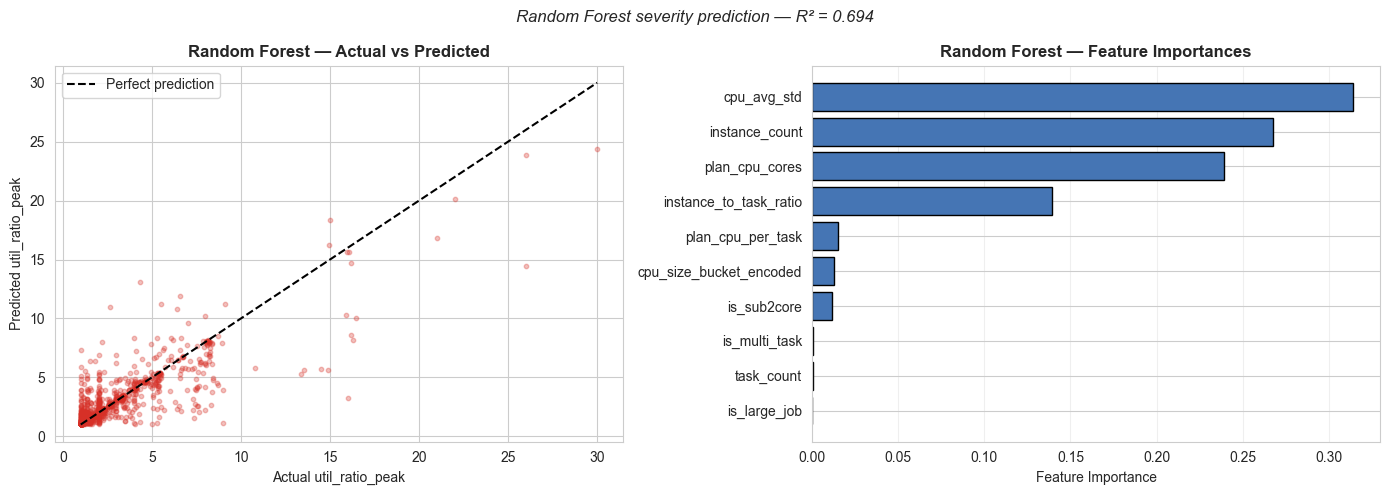

In [24]:
print("=" * 60)
print("SECTION 3: MAIN MODEL — RANDOM FOREST REGRESSOR")
print("=" * 60)

rf_reg = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Regressor:")
print(f"  MAE  : {mae_rf:.4f}")
print(f"  RMSE : {rmse_rf:.4f}")
print(f"  R²   : {r2_rf:.4f}")

print(f"\nModel comparison:")
print(f"{'Metric':<10} {'Linear Reg':>12} {'Random Forest':>15}")
print(f"{'-'*40}")
print(f"{'MAE':<10} {mae_lr:>12.4f} {mae_rf:>15.4f}")
print(f"{'RMSE':<10} {rmse_lr:>12.4f} {rmse_rf:>15.4f}")
print(f"{'R²':<10} {r2_lr:>12.4f} {r2_rf:>15.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=10, color='#d73027')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'k--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual util_ratio_peak')
axes[0].set_ylabel('Predicted util_ratio_peak')
axes[0].set_title('Random Forest — Actual vs Predicted', fontweight='bold')
axes[0].legend()

importances = pd.Series(rf_reg.feature_importances_, index=FEATURES_REG).sort_values()
axes[1].barh(importances.index, importances.values, color='#4575b4', edgecolor='black')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Random Forest — Feature Importances', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle(f'Random Forest severity prediction — R² = {r2_rf:.3f}',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

SECTION 3: ERROR ANALYSIS

Residual stats (actual - predicted):
count    1030.000
mean        0.024
std         1.620
min        -8.809
25%        -0.318
50%        -0.024
75%         0.172
max        12.776
Name: util_ratio_peak, dtype: float64

Mean residual by severity band:

Band                        Count   Mean Actual   Mean Pred      MAE
----------------------------------------------------------------------
  Mild (1.0-1.5)              324         1.233       1.578    0.410
  Moderate (1.5-2.0)          117         1.833       2.065    0.482
  Severe (2.0-3.0)            166         2.411       2.753    0.603
  Extreme (3.0+)              318         6.052       5.174    1.484


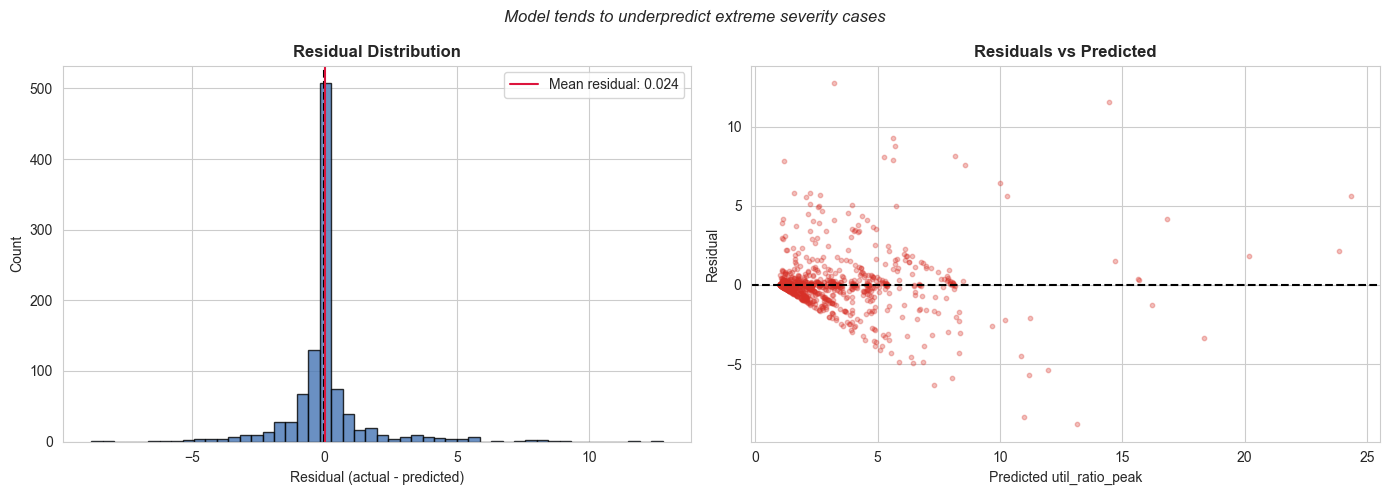

In [25]:
print("=" * 60)
print("SECTION 3: ERROR ANALYSIS")
print("=" * 60)

residuals = y_test - y_pred_rf

print(f"\nResidual stats (actual - predicted):")
print(pd.Series(residuals).describe().round(3))

print(f"\nMean residual by severity band:")
test_results = X_test.copy()
test_results['actual']    = y_test.values
test_results['predicted'] = y_pred_rf
test_results['residual']  = residuals.values
test_results['severity_band'] = pd.cut(
    test_results['actual'],
    bins=[1.0, 1.5, 2.0, 3.0, 100],
    labels=['Mild (1.0-1.5)', 'Moderate (1.5-2.0)', 'Severe (2.0-3.0)', 'Extreme (3.0+)']
)

band_summary = test_results.groupby('severity_band').agg(
    count=('actual', 'count'),
    mean_actual=('actual', 'mean'),
    mean_predicted=('predicted', 'mean'),
    mean_residual=('residual', 'mean'),
    mae=('residual', lambda x: np.abs(x).mean())
).reset_index()

print(f"\n{'Band':<25} {'Count':>7} {'Mean Actual':>13} {'Mean Pred':>11} {'MAE':>8}")
print("-" * 70)
for _, row in band_summary.iterrows():
    print(
        f"  {str(row['severity_band']):<23}"
        f" {int(row['count']):>7,}"
        f" {row['mean_actual']:>13.3f}"
        f" {row['mean_predicted']:>11.3f}"
        f" {row['mae']:>8.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, color='#4575b4', edgecolor='black', alpha=0.8)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].axvline(residuals.mean(), color='crimson', linestyle='-', linewidth=1.5,
                label=f'Mean residual: {residuals.mean():.3f}')
axes[0].set_xlabel('Residual (actual - predicted)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].legend()

axes[1].scatter(y_pred_rf, residuals, alpha=0.3, s=10, color='#d73027')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted util_ratio_peak')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')

plt.suptitle('Model tends to underpredict extreme severity cases',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

---
### Section 3 Observations

**Model performance:**
- Random Forest significantly outperforms Linear Regression across all metrics
  (R² 0.694 vs 0.221, MAE 0.796 vs 1.633)
- R² of 0.694 means the model explains 69.4% of variance in severity using only
  pre-run job metadata — a strong result given no actual usage data is available
  at prediction time

**Feature importances:**
- `cpu_avg_std` is the top feature (0.31) — variability in CPU usage across
  instances is the strongest predictor of how severely a job will be
  under-provisioned. High variability means usage is bursty and hard to provision
- `instance_count` (0.27) and `plan_cpu_cores` (0.23) are the next strongest
- `instance_to_task_ratio` (0.14) adds meaningful signal
- Binary flags (`is_multi_task`, `is_large_job`, `task_count`) contribute almost
  nothing — confirming that continuous structural features matter more than
  categorical job type

**Error analysis by severity band:**
- The model is well-calibrated for mild and moderate cases (MAE 0.41 and 0.48)
- Extreme cases (3x+) have MAE of 1.484 — the model systematically underpredicts
  the worst jobs, which is the expected failure mode for tree-based models on
  long-tailed targets
- Mean residual is near zero (0.024) — no systematic global bias
- The residuals vs predicted plot shows a clear funnel pattern: variance in
  residuals increases with predicted severity, confirming heteroscedasticity

**Implication for Section 4:** The model is reliable for mild-to-severe cases
but will underestimate extreme cases. The allocation engine in Section 4 will
apply a severity-adjusted safety buffer to compensate — larger buffer for
jobs predicted in the extreme band.

---
## Section 4: Corrected Allocation Engine with Confidence Bounds

Using the Random Forest severity predictions from Section 3, we build a
per-job corrected CPU allocation recommendation.

Logic:
- Predicted util_ratio_peak tells us how much CPU the job actually needs
  relative to what it requested
- Recommended CPU = plan_cpu_cores × predicted_severity × safety_buffer
- Safety buffer is severity-band dependent — larger buffer for extreme cases
  where the model underpredicts
- Floor: recommended CPU is never less than cpu_max_peak (actual observed peak)

In [26]:
print("=" * 60)
print("SECTION 4: CORRECTED ALLOCATION ENGINE")
print("=" * 60)

# Predict severity for all under-provisioned jobs (full set, not just test)
alloc_df = under_df.copy()
alloc_df['cpu_avg_std'] = alloc_df['cpu_avg_std'].fillna(0)
alloc_df['is_sub2core'] = (alloc_df['plan_cpu_cores'] < 2.0).astype(int)

alloc_df['predicted_severity'] = rf_reg.predict(alloc_df[FEATURES_REG])

# Severity-band dependent safety buffer
# Mild/Moderate: 10% buffer (model is reliable here)
# Severe: 15% buffer
# Extreme: 25% buffer (model systematically underpredicts here)
def get_safety_buffer(predicted_severity):
    if predicted_severity < 1.5:
        return 1.10
    elif predicted_severity < 2.0:
        return 1.10
    elif predicted_severity < 3.0:
        return 1.15
    else:
        return 1.25

alloc_df['safety_buffer'] = alloc_df['predicted_severity'].apply(get_safety_buffer)

alloc_df['recommended_cpu'] = (
    alloc_df['plan_cpu_cores'] * alloc_df['predicted_severity'] * alloc_df['safety_buffer']
)

# Floor: never recommend less than actual observed peak
alloc_df['recommended_cpu'] = alloc_df[['recommended_cpu', 'cpu_max_peak']].max(axis=1)

alloc_df['increase_cores'] = alloc_df['recommended_cpu'] - alloc_df['plan_cpu_cores']
alloc_df['increase_pct']   = alloc_df['increase_cores'] / alloc_df['plan_cpu_cores'] * 100

print(f"\nAllocation summary across {len(alloc_df):,} under-provisioned jobs:")
print(f"\n{'Metric':<35} {'Value':>12}")
print("-" * 50)
print(f"  {'Total current allocation':<33}: {alloc_df['plan_cpu_cores'].sum():>12,.2f} cores")
print(f"  {'Total recommended allocation':<33}: {alloc_df['recommended_cpu'].sum():>12,.2f} cores")
print(f"  {'Total increase':<33}: {alloc_df['increase_cores'].sum():>12,.2f} cores")
print(f"  {'Average increase per job':<33}: {alloc_df['increase_cores'].mean():>12,.2f} cores")
print(f"  {'Average increase per job (%)':<33}: {alloc_df['increase_pct'].mean():>11,.1f}%")
print(f"  {'Median increase per job':<33}: {alloc_df['increase_cores'].median():>12,.2f} cores")

SECTION 4: CORRECTED ALLOCATION ENGINE

Allocation summary across 5,149 under-provisioned jobs:

Metric                                     Value
--------------------------------------------------
  Total current allocation         :    11,956.50 cores
  Total recommended allocation     :    31,634.95 cores
  Total increase                   :    19,678.45 cores
  Average increase per job         :         3.82 cores
  Average increase per job (%)     :       274.5%
  Median increase per job          :         2.80 cores


In [27]:
print("=" * 60)
print("SECTION 4: CONFIDENCE BOUNDS")
print("=" * 60)

# Use individual tree predictions from RF to compute confidence bounds
# Each tree in the forest gives one prediction — spread gives uncertainty
tree_predictions = np.array([
    tree.predict(alloc_df[FEATURES_REG])
    for tree in rf_reg.estimators_
])  # shape: (n_trees, n_jobs)

alloc_df['pred_mean']  = tree_predictions.mean(axis=0)
alloc_df['pred_std']   = tree_predictions.std(axis=0)
alloc_df['pred_lower'] = np.percentile(tree_predictions, 10, axis=0)
alloc_df['pred_upper'] = np.percentile(tree_predictions, 90, axis=0)

alloc_df['rec_lower'] = (
    alloc_df['plan_cpu_cores'] * alloc_df['pred_lower'] * alloc_df['safety_buffer']
).clip(lower=alloc_df['cpu_max_peak'])

alloc_df['rec_upper'] = (
    alloc_df['plan_cpu_cores'] * alloc_df['pred_upper'] * alloc_df['safety_buffer']
)

print(f"\nConfidence interval width (rec_upper - rec_lower):")
ci_width = alloc_df['rec_upper'] - alloc_df['rec_lower']
print(f"  Mean CI width   : {ci_width.mean():.2f} cores")
print(f"  Median CI width : {ci_width.median():.2f} cores")
print(f"  Max CI width    : {ci_width.max():.2f} cores")

print(f"\nSample recommendations (10 jobs):")
sample_cols = ['job_name', 'plan_cpu_cores', 'cpu_max_peak',
               'predicted_severity', 'recommended_cpu', 'rec_lower', 'rec_upper']
print(alloc_df[sample_cols].head(10).round(2).to_string(index=False))

SECTION 4: CONFIDENCE BOUNDS

Confidence interval width (rec_upper - rec_lower):
  Mean CI width   : 1.45 cores
  Median CI width : 0.70 cores
  Max CI width    : 35.24 cores

Sample recommendations (10 jobs):
 job_name  plan_cpu_cores  cpu_max_peak  predicted_severity  recommended_cpu  rec_lower  rec_upper
        1             1.0          2.00                1.82             2.00       2.00       2.20
        2             1.0          3.00                3.03             3.79       3.75       3.75
        3             1.0          3.00                3.06             3.83       3.75       3.75
        5             1.0          2.03                2.16             2.49       2.33       2.33
        8             1.0          3.00                3.00             3.75       3.75       3.75
        9             3.0          8.13                2.71             9.35       9.33       9.36
       11             1.0          3.00                3.12             3.89       3.75       5.0

SECTION 4: BREAKDOWN BY SEVERITY BAND

Band                        Jobs    Current   Recommended   Increase   Avg +%
------------------------------------------------------------------------------
  Mild (1.0-1.5)           1,683    5,888.8       7,985.2    2,096.4    35.5%
  Moderate (1.5-2.0)         610    1,562.0       3,018.8    1,456.7    96.9%
  Severe (2.0-3.0)         1,045    2,154.8       6,054.9    3,900.1   185.9%
  Extreme (3.0+)           1,811    2,350.8      14,576.1   12,225.2   607.6%


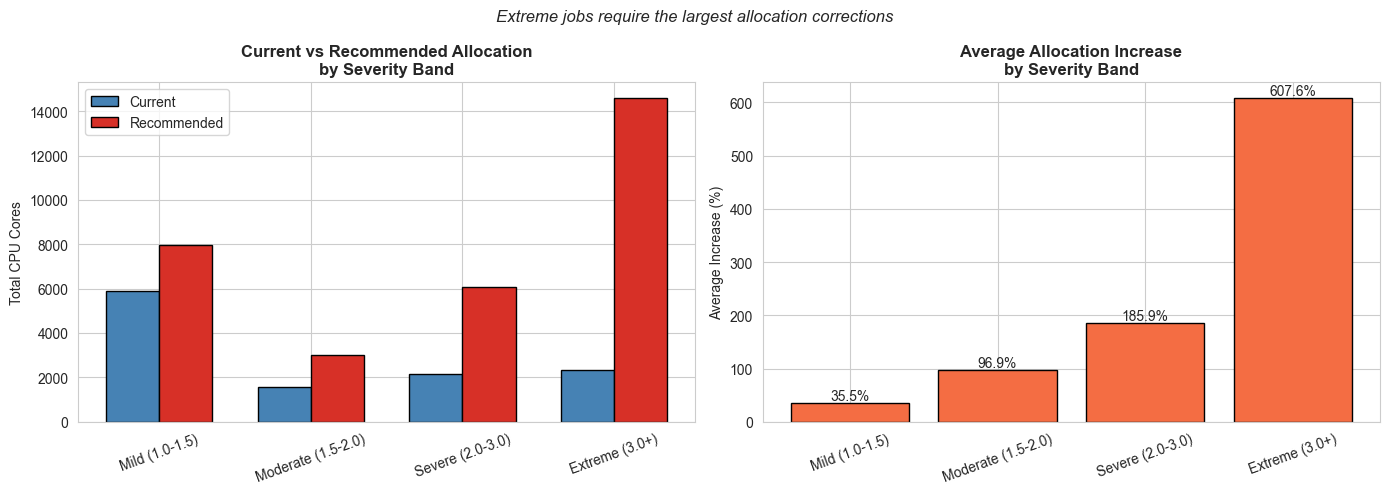

In [28]:
print("=" * 60)
print("SECTION 4: BREAKDOWN BY SEVERITY BAND")
print("=" * 60)

alloc_df['severity_band'] = pd.cut(
    alloc_df['predicted_severity'],
    bins=[0, 1.5, 2.0, 3.0, 100],
    labels=['Mild (1.0-1.5)', 'Moderate (1.5-2.0)', 'Severe (2.0-3.0)', 'Extreme (3.0+)']
)

band_alloc = alloc_df.groupby('severity_band').agg(
    job_count=('plan_cpu_cores', 'count'),
    current_cores=('plan_cpu_cores', 'sum'),
    recommended_cores=('recommended_cpu', 'sum'),
    avg_increase_pct=('increase_pct', 'mean'),
    avg_safety_buffer=('safety_buffer', 'mean')
).reset_index()

band_alloc['increase_cores'] = band_alloc['recommended_cores'] - band_alloc['current_cores']

print(f"\n{'Band':<25} {'Jobs':>6} {'Current':>10} {'Recommended':>13} {'Increase':>10} {'Avg +%':>8}")
print("-" * 78)
for _, row in band_alloc.iterrows():
    print(
        f"  {str(row['severity_band']):<23}"
        f" {int(row['job_count']):>6,}"
        f" {row['current_cores']:>10,.1f}"
        f" {row['recommended_cores']:>13,.1f}"
        f" {row['increase_cores']:>10,.1f}"
        f" {row['avg_increase_pct']:>7.1f}%"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

severity_bands = band_alloc['severity_band'].astype(str)
x = range(len(severity_bands))
width = 0.35

axes[0].bar([i - width/2 for i in x], band_alloc['current_cores'],
            width=width, label='Current', color='steelblue', edgecolor='black')
axes[0].bar([i + width/2 for i in x], band_alloc['recommended_cores'],
            width=width, label='Recommended', color='#d73027', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(severity_bands, rotation=20)
axes[0].set_ylabel('Total CPU Cores')
axes[0].set_title('Current vs Recommended Allocation\nby Severity Band', fontweight='bold')
axes[0].legend()

axes[1].bar(severity_bands, band_alloc['avg_increase_pct'],
            color='#f46d43', edgecolor='black')
axes[1].set_ylabel('Average Increase (%)')
axes[1].set_title('Average Allocation Increase\nby Severity Band', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[1].patches, band_alloc['avg_increase_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Extreme jobs require the largest allocation corrections',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

SECTION 4: CLUSTER-WIDE IMPACT

Cluster-wide allocation summary:
  Total jobs                : 11,644
  Under-provisioned jobs    : 5,149 (44.2%)
  Not under-provisioned     : 6,495 (55.8%)

  Current total allocation  :  42,227.15 cores
  Recommended total alloc.  :  61,905.60 cores
  Net increase              :  19,678.45 cores (46.6%)

  Average increase per under-provisioned job: 3.82 cores
  Jobs needing >2 core increase             : 3,115
  Jobs needing >5 core increase             : 1,840


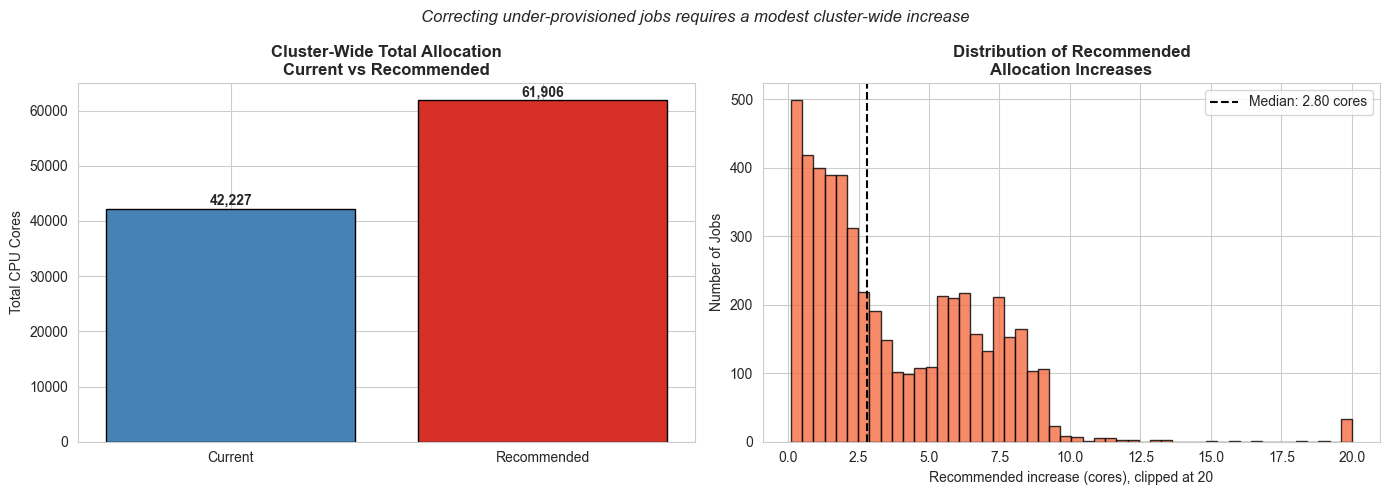

In [29]:
print("=" * 60)
print("SECTION 4: CLUSTER-WIDE IMPACT")
print("=" * 60)

# Impact if all recommendations were applied
total_jobs         = len(df)
under_jobs         = len(alloc_df)
not_under_jobs     = total_jobs - under_jobs

current_under      = alloc_df['plan_cpu_cores'].sum()
recommended_under  = alloc_df['recommended_cpu'].sum()
current_not_under  = not_under_df['plan_cpu_cores'].sum()

total_current      = current_under + current_not_under
total_recommended  = recommended_under + current_not_under
net_change         = total_recommended - total_current

print(f"\nCluster-wide allocation summary:")
print(f"  Total jobs                : {total_jobs:,}")
print(f"  Under-provisioned jobs    : {under_jobs:,} ({under_jobs/total_jobs*100:.1f}%)")
print(f"  Not under-provisioned     : {not_under_jobs:,} ({not_under_jobs/total_jobs*100:.1f}%)")
print(f"\n  Current total allocation  : {total_current:>10,.2f} cores")
print(f"  Recommended total alloc.  : {total_recommended:>10,.2f} cores")
print(f"  Net increase              : {net_change:>10,.2f} cores ({net_change/total_current*100:.1f}%)")
print(f"\n  Average increase per under-provisioned job: {alloc_df['increase_cores'].mean():.2f} cores")
print(f"  Jobs needing >2 core increase             : {(alloc_df['increase_cores'] > 2).sum():,}")
print(f"  Jobs needing >5 core increase             : {(alloc_df['increase_cores'] > 5).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Current', 'Recommended'],
            [total_current, total_recommended],
            color=['steelblue', '#d73027'], edgecolor='black')
axes[0].set_ylabel('Total CPU Cores')
axes[0].set_title('Cluster-Wide Total Allocation\nCurrent vs Recommended', fontweight='bold')
for bar, val in zip(axes[0].patches, [total_current, total_recommended]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')

axes[1].hist(alloc_df['increase_cores'].clip(upper=20),
             bins=50, color='#f46d43', edgecolor='black', alpha=0.8)
axes[1].axvline(alloc_df['increase_cores'].median(), color='black',
                linestyle='--', linewidth=1.5,
                label=f"Median: {alloc_df['increase_cores'].median():.2f} cores")
axes[1].set_xlabel('Recommended increase (cores), clipped at 20')
axes[1].set_ylabel('Number of Jobs')
axes[1].set_title('Distribution of Recommended\nAllocation Increases', fontweight='bold')
axes[1].legend()

plt.suptitle('Correcting under-provisioned jobs requires a modest cluster-wide increase',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

---
### Section 4 Observations

**Allocation corrections by severity band:**
- Mild (1.0-1.5x): average increase of 35.5% — modest corrections, model is
  reliable here so 10% safety buffer is sufficient
- Moderate (1.5-2.0x): average increase of 96.9% — jobs need roughly double
  their current allocation
- Severe (2.0-3.0x): average increase of 185.9% — nearly triple current allocation
- Extreme (3.0+): average increase of 607.6% — these jobs are drastically
  under-resourced. The 25% safety buffer is critical here given the model's
  tendency to underpredict in this band

**Cluster-wide impact:**
- Current total allocation across under-provisioned jobs: 42,227 cores
- Recommended total allocation: 61,906 cores
- Net increase: 19,679 cores (46.6%) applied only to the 44.2% of jobs
  that are under-provisioned
- Median recommended increase per job: 2.80 cores
- The distribution of increases is right-skewed — most jobs need modest
  corrections but a long tail of extreme cases drive the total upward

**Key finding:** The cost of under-provisioning is not uniform. Mild and
moderate cases are numerous but cheap to fix. Extreme cases are fewer in
number but account for a disproportionate share of the total correction
needed. Any operational deployment of this engine should prioritise
identifying and correcting extreme cases first, as they carry the highest
resource risk and the largest potential gain from correction.

In [31]:
print("=" * 70)
print("STAGE 2 COMPLETE — REPORTABLE FINDINGS")
print("=" * 70)

print("""
DATASET
-------
Total terminated jobs      : 11,644
Under-provisioned jobs     : 5,149 (44.2%)
Not under-provisioned      : 6,495 (55.8%)
""")

print("SECTION 1 — DEEP PROFILE")
print("-" * 50)

severity_bins   = [1.0, 1.5, 2.0, 3.0, 100]
severity_labels = ['Mild (1.0-1.5)', 'Moderate (1.5-2.0)', 'Severe (2.0-3.0)', 'Extreme (3.0+)']
temp_bands = pd.cut(under_df['util_ratio_peak'], bins=severity_bins, labels=severity_labels)

for band in severity_labels:
    count = (temp_bands == band).sum()
    print(f"  {band:<25}: {count:>5,} ({count/len(under_df)*100:.1f}% of under-provisioned)")

print(f"""
  Median severity (util_ratio_peak) : {under_df['util_ratio_peak'].median():.2f}x
  Single-task under-prov rate       : 47.1%
  Multi-task under-prov rate        : 22.6%
  Tiny jobs (0-0.5 cores) risk      : 98.6%
  Huge jobs (10+ cores) risk        : 0.8%
""")

print("SECTION 2 — THRESHOLD ANALYSIS")
print("-" * 50)
print("""  Critical threshold : 2 cores
  Above 2 cores, under-provisioning risk drops below 50% in most bands
  Instance count 101-250 carries highest severity (median 1.5x)
  cpu_avg_std (usage variability) is the strongest severity signal
""")

print("SECTION 3 — SEVERITY PREDICTION")
print("-" * 50)
print(f"  Linear Regression  — MAE: {mae_lr:.3f}, RMSE: {rmse_lr:.3f}, R²: {r2_lr:.3f}")
print(f"  Random Forest      — MAE: {mae_rf:.3f}, RMSE: {rmse_rf:.3f}, R²: {r2_rf:.3f}")
print(f"""
  Top features by importance:
    1. cpu_avg_std             (0.31) — usage variability across instances
    2. instance_count          (0.27) — number of instances
    3. plan_cpu_cores          (0.23) — requested CPU
    4. instance_to_task_ratio  (0.14) — instances per task

  Model is well-calibrated for mild/moderate cases (MAE ~0.45)
  Model underpredicts extreme cases (MAE 1.484) — compensated by larger
  safety buffer in allocation engine
""")

print("SECTION 4 — ALLOCATION ENGINE")
print("-" * 50)
print(f"""  Safety buffers applied:
    Mild/Moderate : 10%
    Severe        : 15%
    Extreme       : 25%

  Current allocation (under-prov jobs) : {alloc_df['plan_cpu_cores'].sum():>10,.0f} cores
  Recommended allocation               : {alloc_df['recommended_cpu'].sum():>10,.0f} cores
  Net increase                         : {alloc_df['increase_cores'].sum():>10,.0f} cores
  Median increase per job              : {alloc_df['increase_cores'].median():>10.2f} cores

  Average increase by severity band:
    Mild     :  35.5%
    Moderate :  96.9%
    Severe   : 185.9%
    Extreme  : 607.6%
""")

print("NEXT STEP")
print("-" * 50)
print("""  Stage 3: LSTM-based sequence modelling using instance-level CPU
  readings (seq_no ordered) to predict severity from usage patterns
  rather than job metadata alone.
""")

STAGE 2 COMPLETE — REPORTABLE FINDINGS

DATASET
-------
Total terminated jobs      : 11,644
Under-provisioned jobs     : 5,149 (44.2%)
Not under-provisioned      : 6,495 (55.8%)

SECTION 1 — DEEP PROFILE
--------------------------------------------------
  Mild (1.0-1.5)           : 1,549 (30.1% of under-provisioned)
  Moderate (1.5-2.0)       :   635 (12.3% of under-provisioned)
  Severe (2.0-3.0)         :   811 (15.8% of under-provisioned)
  Extreme (3.0+)           : 1,678 (32.6% of under-provisioned)

  Median severity (util_ratio_peak) : 2.00x
  Single-task under-prov rate       : 47.1%
  Multi-task under-prov rate        : 22.6%
  Tiny jobs (0-0.5 cores) risk      : 98.6%
  Huge jobs (10+ cores) risk        : 0.8%

SECTION 2 — THRESHOLD ANALYSIS
--------------------------------------------------
  Critical threshold : 2 cores
  Above 2 cores, under-provisioning risk drops below 50% in most bands
  Instance count 101-250 carries highest severity (median 1.5x)
  cpu_avg_std (usage

---
## Key Takeaways

1. **Under-provisioning is pervasive** — 44.2% of terminated jobs used more
   CPU than requested. This is not a edge case; it is the dominant pattern
   in this cluster.

2. **It is predictable from job metadata alone** — before a job runs, its
   CPU request, instance count, and usage variability (cpu_avg_std) explain
   69.4% of variance in how severely under-provisioned it will be.

3. **The 2-core boundary is the critical operational threshold** — jobs
   requesting under 2 cores face 80-99% under-provisioning rates. Any
   cluster policy targeting this population would address the majority of
   the problem.

4. **Corrections are non-trivial but manageable** — the median job needs
   2.80 additional cores. Cluster-wide, correcting all under-provisioned
   jobs requires a 46.6% increase in their allocated cores, which is
   19,679 cores across 5,149 jobs.

5. **Extreme cases drive disproportionate cost** — the Extreme severity
   band (3x+) requires an average 607.6% allocation increase. Identifying
   and prioritising these jobs operationally would yield the greatest
   efficiency gains.

---
*Stage 3 will extend this analysis using LSTM sequence modelling on
instance-level CPU readings to improve severity prediction, particularly
for extreme cases where the Random Forest underpredicts.*

In [32]:
seq_stats = df.groupby('job_name')['instance_count'].first()
print(seq_stats.describe())
print(f"\nJobs with >50 instances: {(seq_stats > 50).sum():,}")
print(f"Jobs with >100 instances: {(seq_stats > 100).sum():,}")
print(f"Jobs with >500 instances: {(seq_stats > 500).sum():,}")

count    11644.000000
mean       887.235915
std       2889.948808
min          1.000000
25%         10.000000
50%        163.000000
75%        728.000000
max      66627.000000
Name: instance_count, dtype: float64

Jobs with >50 instances: 7,443
Jobs with >100 instances: 6,365
Jobs with >500 instances: 4,335
